# Zajęcie 8

## Przygotowanie danych

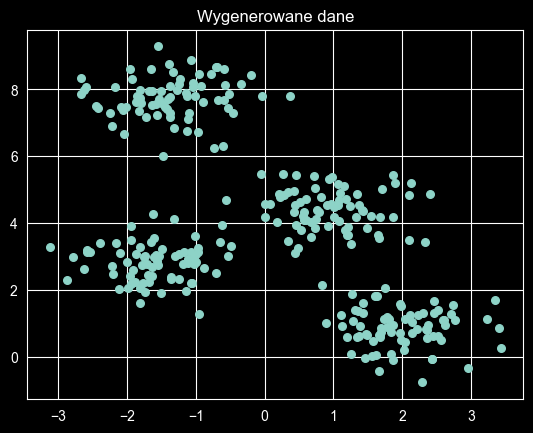

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Wygenerowane dane")
plt.show()

In [75]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
# fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

X_raw = parkinsons_telemonitoring.data.features
#print("Przykładowe cechy medyczne:", list(X_raw.columns[:5]))
X_clean = X_raw.dropna()
scaler = StandardScaler()
X = scaler.fit_transform(X_clean)


## K-means i metoda łokcia

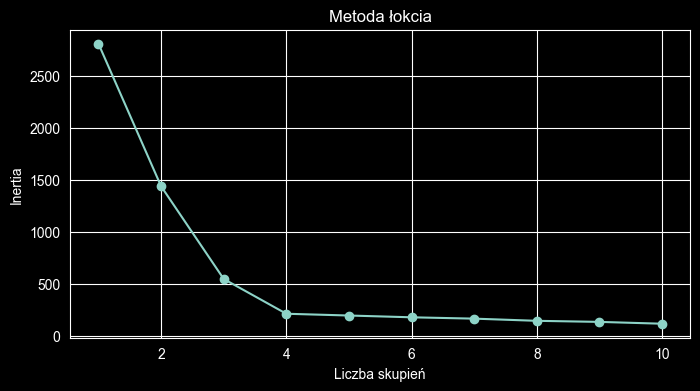

In [2]:
from sklearn.cluster import KMeans
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Liczba skupień")
plt.ylabel("Inertia")
plt.title("Metoda łokcia")
plt.show()

## Wskaźnik Silhouette dla K-means

Liczba skupień=2: silhouette score = 0.45
Liczba skupień=3: silhouette score = 0.59
Liczba skupień=4: silhouette score = 0.68
Liczba skupień=5: silhouette score = 0.58
Liczba skupień=6: silhouette score = 0.49
Liczba skupień=7: silhouette score = 0.50
Liczba skupień=8: silhouette score = 0.40
Liczba skupień=9: silhouette score = 0.40
Liczba skupień=10: silhouette score = 0.34
Liczba skupień=11: silhouette score = 0.34


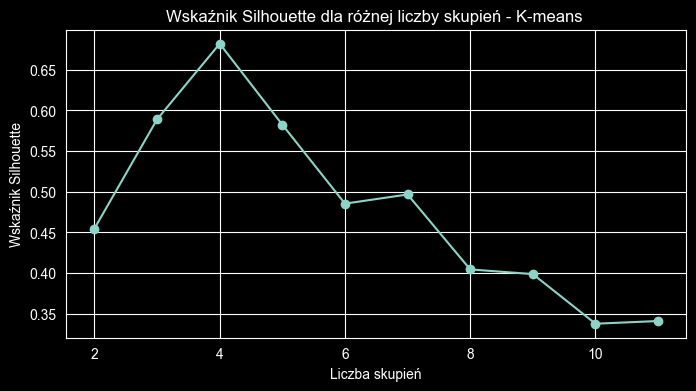

In [3]:
from sklearn.metrics import silhouette_score
#
# kmeans = KMeans(n_clusters=4, random_state=0)
# y_kmeans = kmeans.fit_predict(X)
#
# score = silhouette_score(X, y_kmeans)
# print(f"Wskaźnik Silhouette dla K-means: {score:.2f}")


scores = []
k_values = range(2, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    y_kmeans = kmeans.fit_predict(X)
    score = silhouette_score(X, y_kmeans)
    print(f"Liczba skupień={k}: silhouette score = {score:.2f}")
    scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Liczba skupień")
plt.ylabel("Wskaźnik Silhouette")
plt.title("Wskaźnik Silhouette dla różnej liczby skupień - K-means ")
plt.show()

## DBSCAN i dobór parametrów

eps=0.2: Znaleziono klastrów = 9
eps=0.2: silhouette score = -0.36


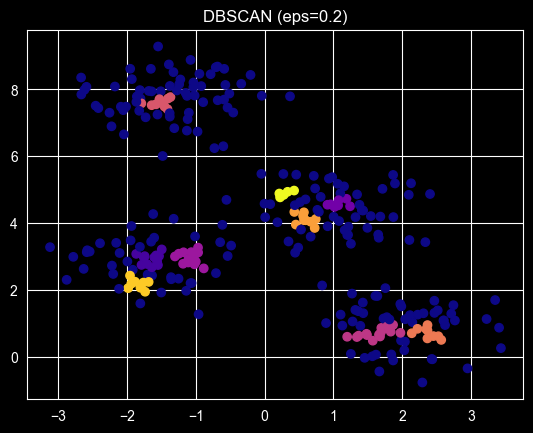

eps=0.3: Znaleziono klastrów = 11
eps=0.3: silhouette score = -0.03


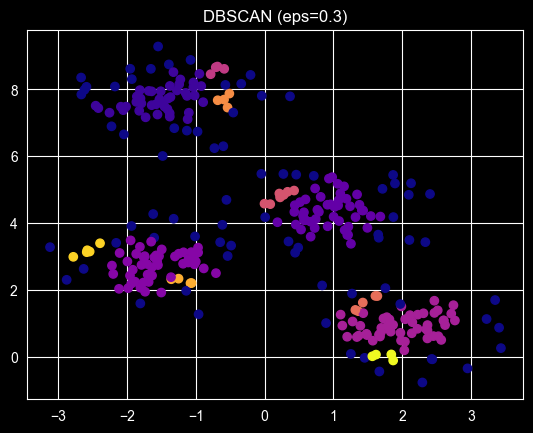

eps=0.5: Znaleziono klastrów = 4
eps=0.5: silhouette score = 0.63


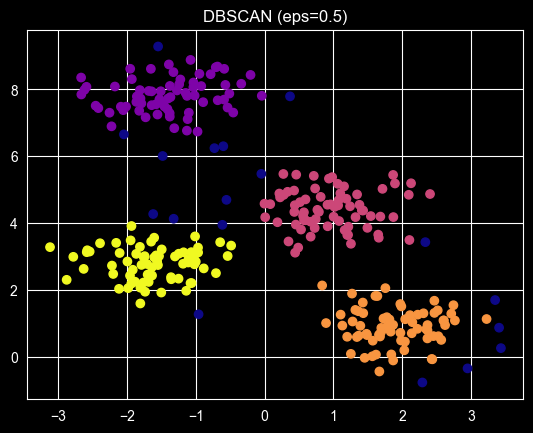

eps=0.7: Znaleziono klastrów = 3
eps=0.7: silhouette score = 0.56


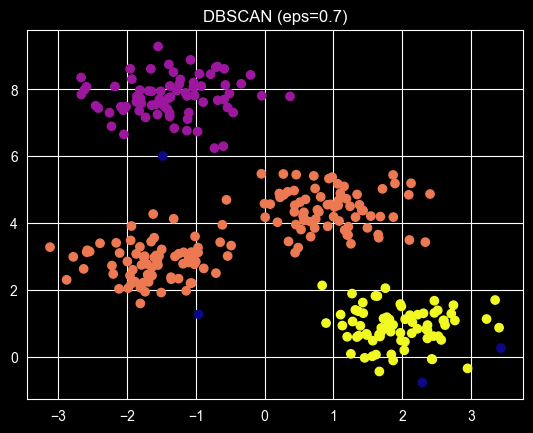

In [4]:
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.metrics import silhouette_score

# Test kilku wartości eps
eps_values = [0.2, 0.3, 0.5, 0.7]
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps}: Znaleziono klastrów = {n_clusters}")
    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)
        print(f"eps={eps}: silhouette score = {score:.2f}")

    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
    plt.title(f"DBSCAN (eps={eps})")
    plt.show()



eps=0.2: silhouette score = -0.36
eps=0.3: silhouette score = -0.03
eps=0.4: silhouette score = 0.48
eps=0.5: silhouette score = 0.63
eps=0.6: silhouette score = 0.66
eps=0.7: silhouette score = 0.56
eps=0.8: silhouette score = 0.59
eps=0.9: silhouette score = 0.59


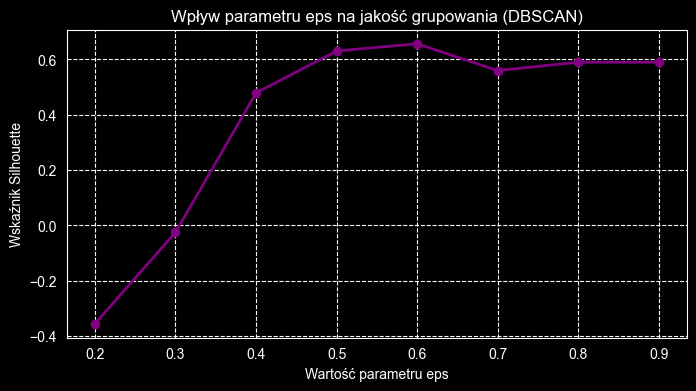

In [5]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
silhouette_scores = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)
        print(f"eps={eps}: silhouette score = {score:.2f}")
        silhouette_scores.append(score)

if len(silhouette_scores) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(eps_values, silhouette_scores, marker='o', linestyle='-', color='purple', linewidth=2)
    plt.xlabel("Wartość parametru eps")
    plt.ylabel("Wskaźnik Silhouette")
    plt.title("Wpływ parametru eps na jakość grupowania (DBSCAN)")
    plt.grid(True, linestyle='--')
    plt.show()
else:
    print("Nie wygenerowano wykresu")

eps=0.2: liczba skupień= 9, silhouette score = -0.36
eps=0.3: liczba skupień= 11, silhouette score = -0.03
eps=0.4: liczba skupień= 5, silhouette score = 0.48
eps=0.5: liczba skupień= 4, silhouette score = 0.63
eps=0.6: liczba skupień= 4, silhouette score = 0.66
eps=0.7: liczba skupień= 3, silhouette score = 0.56
eps=0.8: liczba skupień= 3, silhouette score = 0.59
eps=0.9: liczba skupień= 3, silhouette score = 0.59


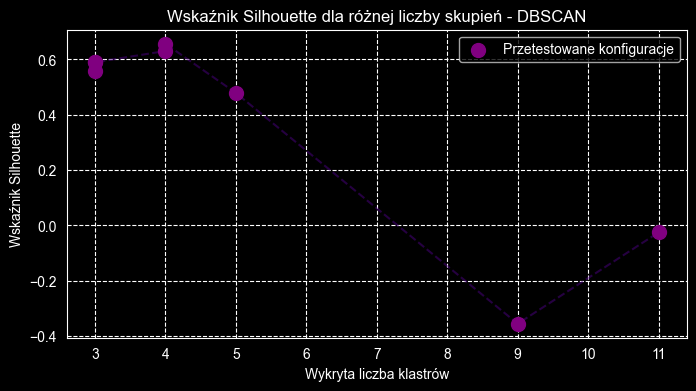

In [6]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
silhouette_scores = []
clusters_counts = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)
        print(f"eps={eps}: liczba skupień= {n_clusters}, silhouette score = {score:.2f}")

        silhouette_scores.append(score)
        clusters_counts.append(n_clusters)

if len(silhouette_scores) > 0:
    plt.figure(figsize=(8, 4))
    plt.scatter(clusters_counts, silhouette_scores, color='purple', s=100, zorder=3, label='Przetestowane konfiguracje')

    sorted_indices = np.argsort(clusters_counts)
    plt.plot(np.array(clusters_counts)[sorted_indices], np.array(silhouette_scores)[sorted_indices],
             linestyle='--', color='indigo', alpha=0.5)
    plt.xlabel("Wykryta liczba klastrów")
    plt.ylabel("Wskaźnik Silhouette")
    plt.title("Wskaźnik Silhouette dla różnej liczby skupień - DBSCAN")
    plt.xticks(range(min(clusters_counts), max(clusters_counts) + 1))
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.show()
else:
    print("Nie wygenerowano wykresu")

## Agglomerative Clustering i dendrogram

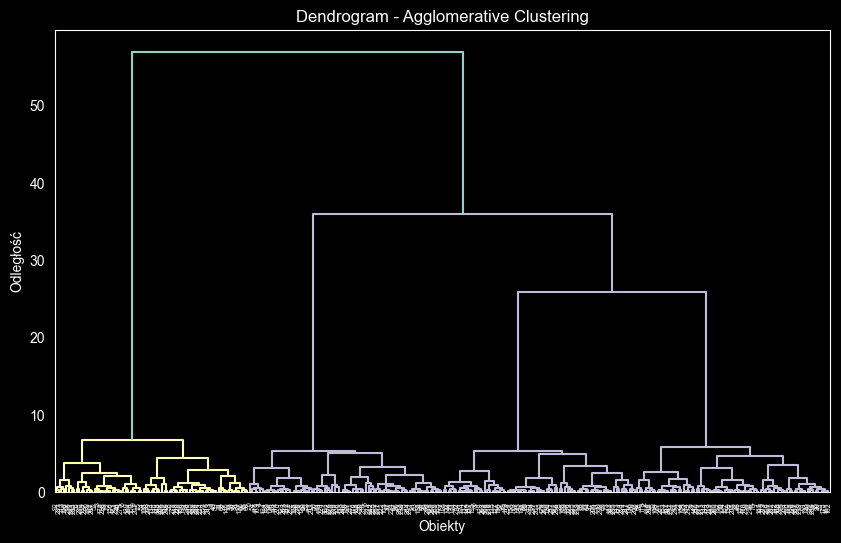

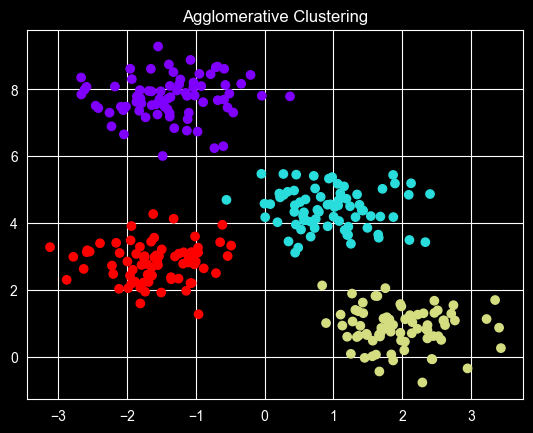

In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, 'ward')
plt.figure(figsize=(10, 6))
plt.grid(False)
dendrogram(linked)
plt.title("Dendrogram - Agglomerative Clustering")
plt.xlabel("Obiekty")
plt.ylabel("Odległość")
plt.show()

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='rainbow')
#plt.scatter(X[:, 4], X[:, 5], c=labels_agg, cmap='rainbow')
plt.title("Agglomerative Clustering")
plt.show()

Liczba skupień k=2: silhouette score = 0.55
Liczba skupień k=3: silhouette score = 0.59
Liczba skupień k=4: silhouette score = 0.68
Liczba skupień k=5: silhouette score = 0.59
Liczba skupień k=6: silhouette score = 0.49
Liczba skupień k=7: silhouette score = 0.38
Liczba skupień k=8: silhouette score = 0.29
Liczba skupień k=9: silhouette score = 0.31
Liczba skupień k=10: silhouette score = 0.32


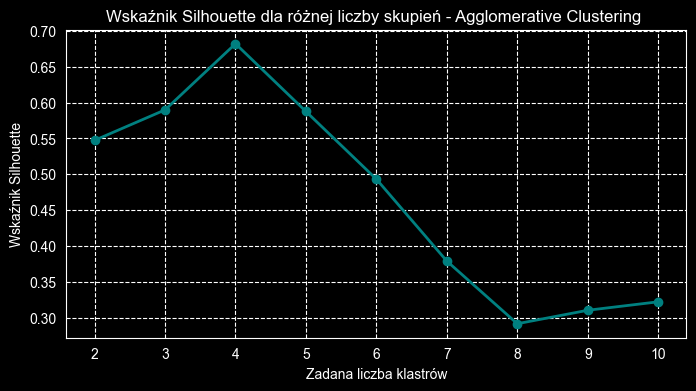

In [9]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    agg_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg_model.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"Liczba skupień k={k}: silhouette score = {score:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='teal', linewidth=2)
plt.xlabel("Zadana liczba klastrów")
plt.ylabel("Wskaźnik Silhouette")
plt.title("Wskaźnik Silhouette dla różnej liczby skupień - Agglomerative Clustering ")
plt.xticks(k_values)
plt.grid(True, linestyle='--')
plt.show()

## Kryteria Calinskiego-Harabasza i Daviesa-Bouldina

In [10]:

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("Calinski-Harabasz:", calinski_harabasz_score(X, y_kmeans))
print("Davies-Bouldin:", davies_bouldin_score(X, y_kmeans))

Calinski-Harabasz: 751.3769068198395
Davies-Bouldin: 0.9663466277658075
